In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

date_str = datetime.now().strftime("%Y%m%d")
root = Path("results")
csv_files = list(root.glob("*/periodic_image_distance_*/pi_dist_summary_*.csv"))
print(f"Found {len(csv_files)} CSV files.")

dfs = []

for f in csv_files:
    pdbid = f.parts[-3]
    df = pd.read_csv(f)
    df["pdb"] = pdbid
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

display(df_all.head())
print(df_all.columns)
print(df_all["pdb"].unique())
print(df_all.shape)

Found 100 CSV files.


,pdb,replica,xtc,xvg,n_frames,min_dist_nm,max_dist_nm,mean_dist_nm,median_dist_nm,p01_dist_nm,p05_dist_nm,p95_dist_nm,p99_dist_nm,status
0,5s2e,0,cleaned_5s2e_0.xtc,pi_dist_5s2e_0.xvg,10001,1.402,2.296,1.920370,1.932,1.589,1.692,2.109,2.163,ok
1,5s2e,1,cleaned_5s2e_1.xtc,pi_dist_5s2e_1.xvg,10001,1.243,2.291,1.898573,1.919,1.487,1.619,2.108,2.164,ok
2,5s2e,2,cleaned_5s2e_2.xtc,pi_dist_5s2e_2.xvg,10001,1.000,2.250,1.886851,1.912,1.337,1.571,2.103,2.166,ok
3,5s2e,3,cleaned_5s2e_3.xtc,pi_dist_5s2e_3.xvg,10001,1.122,2.274,1.936945,1.948,1.620,1.725,2.115,2.165,ok
4,5s2e,4,cleaned_5s2e_4.xtc,pi_dist_5s2e_4.xvg,10001,1.012,2.259,1.911506,1.932,1.428,1.638,2.111,2.164,ok


Index(['pdb', 'replica', 'xtc', 'xvg', 'n_frames', 'min_dist_nm',
       'max_dist_nm', 'mean_dist_nm', 'median_dist_nm', 'p01_dist_nm',
       'p05_dist_nm', 'p95_dist_nm', 'p99_dist_nm', 'status'],
      dtype='object')
['5s2e' '1ncx' '2bem' '7p8f' '1l0c' '1xyh' '6ghh' '5s3v' '7gzz' '4ykw'
 '5kch' '1vc1' '5b08' '7due' '8okr' '3a8c' '6el5' '8den' '7f2b' '7y05'
 '1hia' '4dg4' '2znt' '8az4' '2gg7' '3m3x' '4rfz' '4ded' '7nns' '6bsk'
 '2aps' '8bpt' '5fns' '2p16' '2c2l' '1yxv' '1ptz' '8uut' '7d2d' '1m2r'
 '8wtr' '8c8s' '5osu' '7ons' '5fp8' '4gub' '5c1w' '3giv' '4a39' '8roo'
 '3t00' '2hla' '2q11' '8erx' '8gs9' '4j0j' '6eh8' '1ggp' '7xed' '2qhr'
 '7n6h' '2mcp' '5zr8' '2vff' '9jdq' '1fof' '9j5z' '1a7u' '3b9c' '1yvx'
 '1zty' '3d6d' '6qpm' '8bdp' '7wpi' '4dme' '3nxb' '5j7e' '1wy9' '3ef4'
 '7lak' '3era' '1onl' '4hoi' '7n3z' '1nbq' '8skm' '1kap' '4azu' '8spm'
 '3h90' '1dxx' '4xqa' '5rsi' '1p27' '7bru' '2vfd' '4k0y' '6typ']
(998, 14)


In [7]:
df_all.to_csv(root / f"periodic_image_distance_summary.csv", index=False)    

In [2]:
df_min = df_all.groupby("pdb")["min_dist_nm"].min().reset_index()
display(df_min.head())
display(df_min.shape[0])

idx = df_all.groupby("pdb")["min_dist_nm"].idxmin()

df_min_rows = df_all.loc[idx].reset_index(drop=True)

display(df_min_rows)

,pdb,min_dist_nm
0,1a7u,0.237
1,1dxx,0.296
2,1fof,1.109
3,1ggp,1.122
4,1hia,1.077


99

,pdb,replica,xtc,xvg,n_frames,min_dist_nm,max_dist_nm,mean_dist_nm,median_dist_nm,p01_dist_nm,p05_dist_nm,p95_dist_nm,p99_dist_nm,status
0,1a7u,7,cleaned_1a7u_7.xtc,pi_dist_1a7u_7.xvg,10001,0.237,1.938,0.306751,0.285,0.253,0.261,0.342,1.072,ok
1,1dxx,4,cleaned_1dxx_4.xtc,pi_dist_1dxx_4.xvg,10001,0.296,2.225,1.433515,1.459,0.492,0.763,1.984,2.077,ok
2,1fof,1,cleaned_1fof_1.xtc,pi_dist_1fof_1.xvg,10001,1.109,2.051,1.675891,1.689,1.332,1.431,1.868,1.924,ok
3,1ggp,2,cleaned_1ggp_2.xtc,pi_dist_1ggp_2.xvg,10001,1.122,2.533,1.948108,1.947,1.385,1.510,2.358,2.431,ok
4,1hia,9,cleaned_1hia_9.xtc,pi_dist_1hia_9.xvg,10001,1.077,2.204,1.708294,1.705,1.414,1.492,1.934,2.023,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,8spm,1,cleaned_8spm_1.xtc,pi_dist_8spm_1.xvg,10001,1.152,2.259,1.720090,1.716,1.345,1.425,2.019,2.102,ok
95,8uut,1,cleaned_8uut_1.xtc,pi_dist_8uut_1.xvg,10001,1.060,2.107,1.812574,1.817,1.569,1.660,1.954,2.004,ok
96,8wtr,8,cleaned_8wtr_8.xtc,pi_dist_8wtr_8.xvg,10001,0.736,2.061,1.702776,1.724,1.224,1.428,1.904,1.963,ok
97,9j5z,6,cleaned_9j5z_6.xtc,pi_dist_9j5z_6.xvg,10001,1.085,2.545,2.065715,2.074,1.694,1.814,2.296,2.380,ok


In [3]:
# Load monomer/multimer annotation
st_df = pd.read_csv(root / "000analysis" / "pdb_monomer_multimer_status.csv")

# Use your minimum-distance dataframe
pi_df = df_min_rows.copy()   # full rows at minimum min_dist_nm
# or: pi_df = df_min.copy()  # only pdb + min_dist_nm

# Standardise PDB IDs
pi_df["pdb"] = pi_df["pdb"].astype(str).str.strip().str.lower()
st_df["PDB"] = st_df["PDB"].astype(str).str.strip().str.lower()

# Merge chain-state annotation
pi_checked = pi_df.merge(
    st_df[["PDB", "State", "Chains"]],
    left_on="pdb",
    right_on="PDB",
    how="left"
)

# Clean up duplicate PDB column
pi_checked = pi_checked.drop(columns=["PDB"])

# Put important columns first
first_cols = ["pdb", "xtc", "min_dist_nm", "State", "Chains"]
other_cols = [c for c in pi_checked.columns if c not in first_cols]
pi_checked = pi_checked[first_cols]

display(pi_checked.head())

mono_df_sorted = pi_checked.sort_values(
    by="min_dist_nm",
    ascending=True
)

display(mono_df_sorted.head(20))

# Save
pi_checked.to_csv(
    root / "000analysis" / f"pi_dist_chainstate_minonly_{date_str}.csv",
    index=False
)

mono_df_sorted.to_csv(
    root / "000analysis" / f"sorted_mindist_{date_str}.csv",
    index=False
)

,pdb,xtc,min_dist_nm,State,Chains
0,1a7u,cleaned_1a7u_7.xtc,0.237,Multimer (2 chains),2
1,1dxx,cleaned_1dxx_4.xtc,0.296,Multimer (4 chains),4
2,1fof,cleaned_1fof_1.xtc,1.109,Multimer (2 chains),2
3,1ggp,cleaned_1ggp_2.xtc,1.122,Multimer (2 chains),2
4,1hia,cleaned_1hia_9.xtc,1.077,Multimer (6 chains),6


,pdb,xtc,min_dist_nm,State,Chains
8,1nbq,cleaned_1nbq_3.xtc,0.112,Multimer (2 chains),2
5,1kap,cleaned_1kap_2.xtc,0.232,Multimer (2 chains),2
32,3b9c,cleaned_3b9c_6.xtc,0.235,Multimer (4 chains),4
0,1a7u,cleaned_1a7u_7.xtc,0.237,Multimer (2 chains),2
21,2c2l,cleaned_2c2l_2.xtc,0.239,Multimer (8 chains),8
35,3era,cleaned_3era_1.xtc,0.250,Multimer (2 chains),2
91,8okr,cleaned_8okr_9.xtc,0.250,Multimer (24 chains),24
37,3h90,cleaned_3h90_4.xtc,0.252,Multimer (4 chains),4
72,7due,cleaned_7due_0.xtc,0.256,Multimer (2 chains),2
84,8az4,cleaned_8az4_6.xtc,0.261,Multimer (10 chains),10


In [4]:
#check distribution of monomeric state mindist


# Keep only monomeric entries
mono_df = pi_checked[
    pi_checked["State"]
    .astype(str)
    .str.lower()
    .str.contains("monomer")
].copy()

print(f"Number of monomeric entries: {len(mono_df)}")

display(mono_df.head())

Number of monomeric entries: 37


,pdb,xtc,min_dist_nm,State,Chains
6,1l0c,cleaned_1l0c_1.xtc,0.467,Monomer,1
7,1m2r,cleaned_1m2r_5.xtc,0.677,Monomer,1
9,1ncx,cleaned_1ncx_1.xtc,0.560,Monomer,1
14,1wy9,cleaned_1wy9_8.xtc,0.455,Monomer,1
15,1xyh,cleaned_1xyh_7.xtc,0.332,Monomer,1


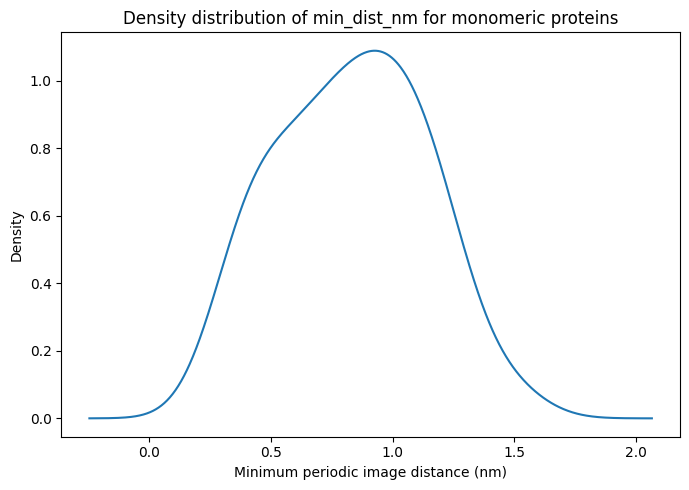

count    37.000000
mean      0.830811
std       0.299998
min       0.332000
25%       0.617000
50%       0.846000
75%       1.075000
max       1.488000
Name: min_dist_nm, dtype: float64

In [5]:
mono_df["min_dist_nm"].plot(
    kind="density",
    figsize=(7,5)
)

plt.xlabel("Minimum periodic image distance (nm)")
plt.title("Density distribution of min_dist_nm for monomeric proteins")

plt.tight_layout()
plt.show()
mono_df["min_dist_nm"].describe()

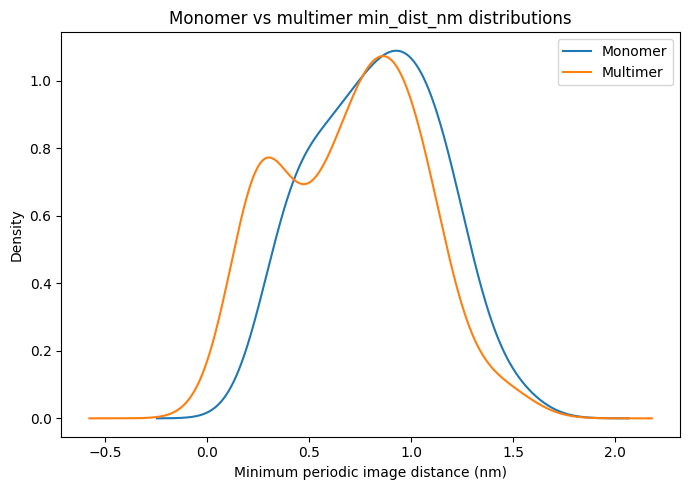

In [6]:
plt.figure(figsize=(7,5))

for state in ["Monomer", "Multimer"]:
    subset = pi_checked[
        pi_checked["State"]
        .astype(str)
        .str.lower()
        .str.contains(state.lower())
    ]

    subset["min_dist_nm"].plot(
        kind="density",
        label=state
    )

plt.xlabel("Minimum periodic image distance (nm)")
plt.title("Monomer vs multimer min_dist_nm distributions")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
#scatter plot for all mindist values, colored by state

df_psummary = pd.read_csv(root / "periodic_image_distance_summary.csv")

plt.figure(figsize=(8,6))
for state in ["Monomer", "Multimer"]:
    subset = df_psummary[
        df_psummary["State"]
        .astype(str)
        .str.lower()
        .str.contains(state.lower())
    ]

    plt.scatter(
        subset.index,
        subset["min_dist_nm"],
        label=state,
        alpha=0.6
    )

plt.xlabel("Index")
plt.ylabel("Minimum periodic image distance (nm)")
plt.title("Scatter plot of min_dist_nm by state")
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'State'

<Figure size 800x600 with 0 Axes>

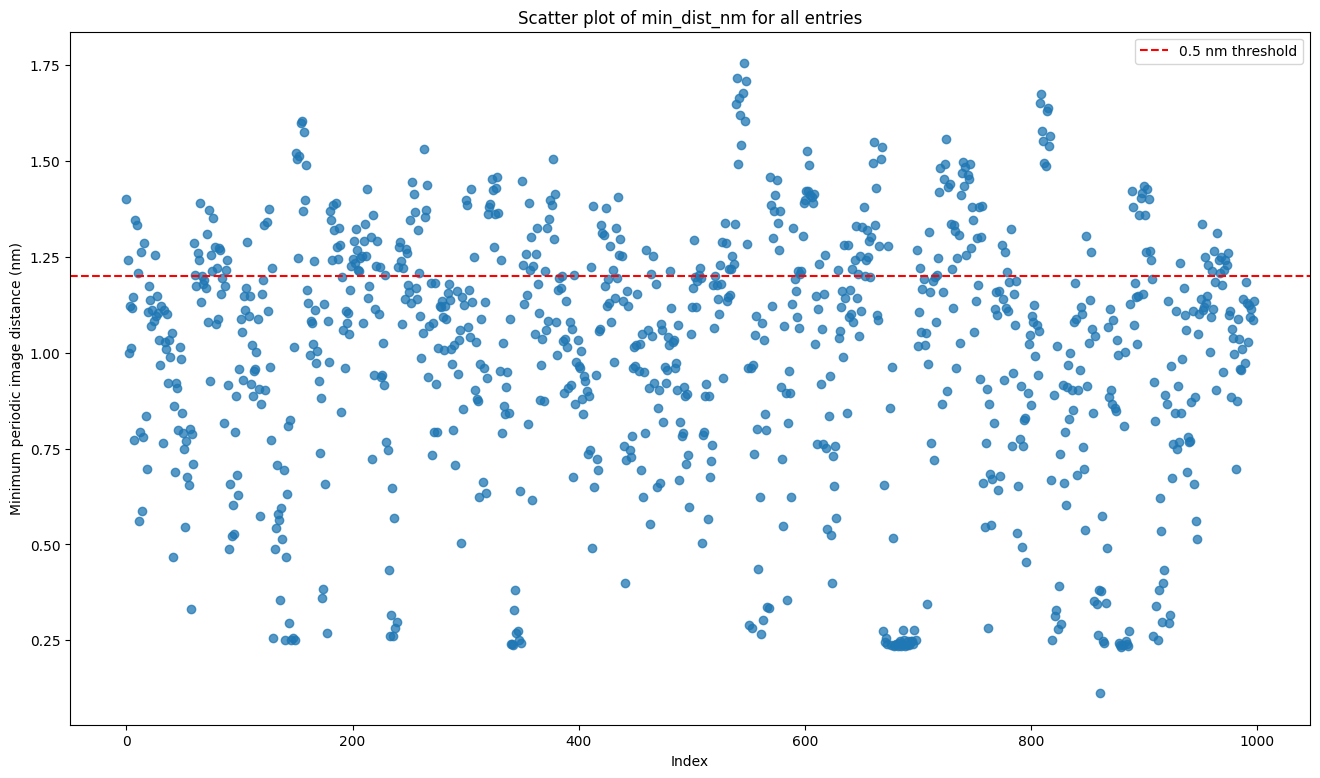

In [27]:
#scatter plot for all mindist values

plt.figure(figsize=(16,9))
plt.scatter(
    df_psummary.index,
    df_psummary["min_dist_nm"],
    alpha=0.75
)  
plt.axhline(y=1.2, color='red', linestyle='--', label='0.5 nm threshold')  # Add threshold line
plt.xlabel("Index")
plt.ylabel("Minimum periodic image distance (nm)")
plt.title("Scatter plot of min_dist_nm for all entries")
plt.legend()
plt.fontsize = 24
#plt.tight_layout()
plt.show()

In [30]:
threshold = 1.2  # nm; change this

problem_per_pdb = (
    df_all.assign(problem=df_all["min_dist_nm"] < threshold)
    .groupby("pdb")
    .agg(
        n_problem_replicas=("problem", "sum"),
        n_total_replicas=("xtc", "count"),
        worst_min_dist_nm=("min_dist_nm", "min"),
    )
    .reset_index()
)

problem_per_pdb["fraction_problem"] = (
    problem_per_pdb["n_problem_replicas"] /
    problem_per_pdb["n_total_replicas"]
)

problem_per_pdb = problem_per_pdb.sort_values(
    ["n_problem_replicas", "worst_min_dist_nm"],
    ascending=[False, True]
)

display(problem_per_pdb)

problem_per_pdb.to_csv(
    root / "000analysis" / f"problem_replicas_per_pdb_{date_str}.csv",
    index=False
)

,pdb,n_problem_replicas,n_total_replicas,worst_min_dist_nm,fraction_problem
32,3b9c,20,20,0.235,1.0
8,1nbq,10,10,0.112,1.0
5,1kap,10,10,0.232,1.0
21,2c2l,10,10,0.239,1.0
35,3era,10,10,0.250,1.0
...,...,...,...,...,...
85,8bdp,0,10,1.255,0.0
55,5fns,0,10,1.276,0.0
77,7n6h,0,10,1.390,0.0
75,7lak,0,10,1.488,0.0
